# **Customer Reviews Analysis**

### Scenario

Imagine you have just joined a mid-sized analytics firm where new clients regularly ask for help across diverse problem areas. In this lab, we will work through **three tasks** that represent common challenges faced by junior data scientists:

1. **Natural Language Processing (NLP)**
2. **Time Series Forecasting**
3. **Neural Network Modeling**

**In this notebook, we will be focusing on the first task: Natural Language Processing (NLP).** You’ve been given a collection of customer reviews, and your task is to preprocess and analyze the text to identify common words and phrases. These insights can help the organization better understand customer sentiment and product experiences.


## **Step 1: Data Exploration and Preprocessing**

### 1.1 Imports and loading the data.

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re                       # Regular expressions for text cleaning
import string                   # String operations and punctuation handling
from collections import Counter # Counting word frequencies


# For text preprocessing
import nltk                              # Natural Language Toolkit for NLP
from nltk.tokenize import word_tokenize, sent_tokenize  # Split text into words and sentences
from nltk.corpus import stopwords        # Provides common words to remove
from nltk.stem import PorterStemmer, WordNetLemmatizer  # Stemming and lemmatization
from nltk.util import ngrams              # Creating n-grams such as bigrams and trigrams


# Download necessary NLTK data
nltk.download('punkt')                         # Tokenization resources
nltk.download('stopwords')                     # Stopword list
nltk.download('wordnet')                       # WordNet for lemmatization
nltk.download('averaged_perceptron_tagger')   # Part-of-speech tagging
nltk.download('punkt_tab')                    # Additional tokenization data
nltk.download('averaged_perceptron_tagger_eng') # English POS tagging data


# For dataset loading
from sklearn.datasets import fetch_20newsgroups  # Loads the 20 Newsgroups dataset


# Set random seed for reproducibility
np.random.seed(42)  # Ensures consistent results when using random operations


# Load the Amazon reviews dataset
df = pd.read_csv('amazon_reviews_lab.csv')

# check to see its loaded
print(f"Dataset shape: {df.head()}")

Dataset shape:    product_id  rating                                        review_text  \
0  6301977173       2  This film is definitely not for anyone who is ...   
1  6301977173       5  This movie was playing at Radio City Music Hal...   
2  6301977173       1  I would love to buy this movie as I have been ...   
3  6301977173       1  The advertisment for this DVD on Amazon was in...   
4  9575871979       5  I bought some of these to try with a light usi...   

                              review_summary review_time_raw  \
0  The best of Mark Twain's work - left out!     05 12, 2000   
1            The best Tom Sawyer i ever saw.     08 26, 2002   
2                         Why no Widescreen?      08 6, 2005   
3              False advertising on this DVD     09 11, 2005   
4                               Work GREAT!!     10 15, 2007   

   unix_review_time   timestamp sentiment_label  review_length_words  
0      9.580896e+08  2000-05-12        negative                  302  
1

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


## 1.2 Data Exploration

The dataset was examined to understand its **size, structure, completeness, ratings, and sentiment distribution**. This is to provides a clear picture of the data and help identify patterns or imbalances that may affect the NLP analysis.


### 1.21 Data Exploration


In [ ]:
# Dataset size
print("Dataset shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Basic information
print("\nDataset information:")
df.info()

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Rating distribution
print("\nRating distribution:")
print(df['rating'].value_counts().sort_index())

# Sentiment distribution
print("\nSentiment distribution:")
print(df['sentiment_label'].value_counts())

# Preview the reviews
print("\nFirst 5 reviews:")
display(df[['rating', 'review_text', 'sentiment_label']].head())

Dataset shape: (997, 9)

Columns:
['product_id', 'rating', 'review_text', 'review_summary', 'review_time_raw', 'unix_review_time', 'timestamp', 'sentiment_label', 'review_length_words']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 997 entries, 0 to 996
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           997 non-null    object 
 1   rating               997 non-null    int64  
 2   review_text          997 non-null    object 
 3   review_summary       997 non-null    object 
 4   review_time_raw      997 non-null    object 
 5   unix_review_time     997 non-null    float64
 6   timestamp            997 non-null    object 
 7   sentiment_label      997 non-null    object 
 8   review_length_words  997 non-null    int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 70.2+ KB

Missing values:
product_id             0
rating                 0
review_t

,rating,review_text,sentiment_label
0,2,This film is definitely not for anyone who is ...,negative
1,5,This movie was playing at Radio City Music Hal...,positive
2,1,I would love to buy this movie as I have been ...,negative
3,1,The advertisment for this DVD on Amazon was in...,negative
4,5,I bought some of these to try with a light usi...,positive


The dataset contains 997 Amazon reviews across 9 variables, with no missing values. The rating distribution is strongly concentrated around 5-star reviews (580), while 1- and 2-star reviews are less common. This is also reflected in the sentiment distribution, where 768 reviews are positive, compared with 135 negative and 94 neutral reviews. The review lengths vary considerably, showing that some customers provide very short comments while others give much more detailed feedback.

### 1.22 Word Count

In [ ]:
# Descriptive statistics for all columns
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
product_id,997,40,0972683275,218,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,997.0,NaN,NaN,NaN,4.129388,1.280181,1.0,4.0,5.0,5.0,5.0
review_text,997,997,"perfect, as described Thank you",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_summary,997,938,Works great,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_time_raw,997,722,"09 18, 2013",6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
unix_review_time,997.0,NaN,NaN,NaN,1344766257.171515,44114204.839312,958089600.0,1311897600.0,1356048000.0,1379462400.0,1405555200.0
timestamp,997,722,2013-09-18,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sentiment_label,997,3,positive,768,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_length_words,997.0,NaN,NaN,NaN,146.374122,216.12677,5.0,32.0,67.0,165.0,2079.0



The review text shows **997 unique reviews**, meaning there are no duplicate review texts in the dataset. The reviews vary greatly in length, ranging from **5 to 2,079 words**, with an average of about **146 words** and a median of **67 words**. The difference between the mean and median shows that a small number of very long reviews increase the average. This variation in review length is important for NLP because the text will need to be cleaned and standardized before analyzing word frequencies and patterns.


### 1.3 Ratings, Sentiments and length of review distribution

#### 1.31 Rating Distribution

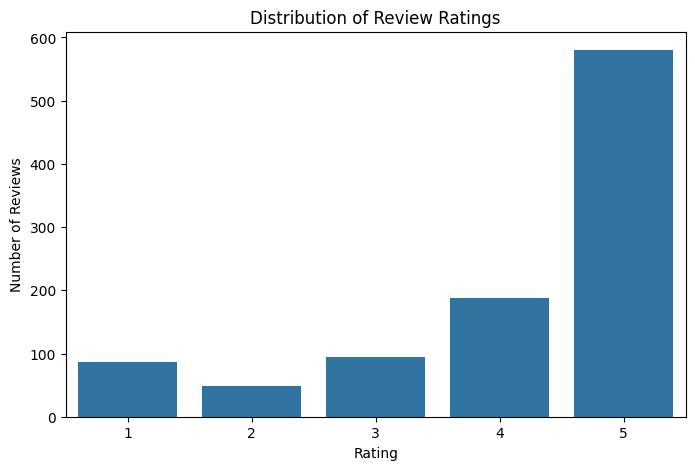

In [ ]:
# Plot the distribution of ratings
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='rating')

plt.title('Distribution of Review Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.show()

#### 1.32 Sentiment Distribution

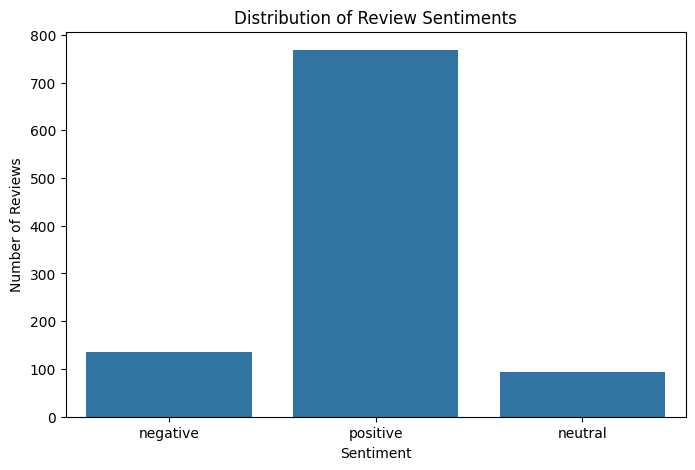

In [ ]:
# Plot the distribution of sentiment labels
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='sentiment_label')

plt.title('Distribution of Review Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

#### 1.33 Review Length Distribution

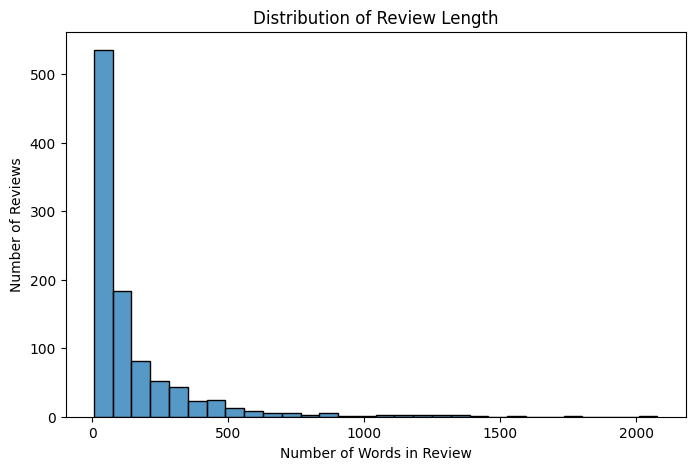

In [ ]:
# Plot the distribution of review word lengths
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='review_length_words', bins=30)

plt.title('Distribution of Review Length')
plt.xlabel('Number of Words in Review')
plt.ylabel('Number of Reviews')
plt.show()


The three visualizations show that the dataset is generally dominated by **positive and high-rated reviews**, with 5-star ratings and positive sentiment having the highest frequencies. In contrast, lower ratings and negative or neutral sentiments occur much less often, indicating an **imbalanced dataset** that is largely positive. The review-length distribution is **right-skewed**, meaning most reviews are relatively short, while a small number are much longer, with the longest reaching 2,079 words. Overall, these patterns show that the dataset contains mainly satisfied customers but considerable variation in review length, which is important to consider during later NLP preprocessing and sentiment analysis.


### 1.4 Reflection: Text Preprocessing

Our review text contains natural language such as *“This film is definitely not for anyone…”*. Before analyzing the reviews, we need to standardize the text so that unnecessary differences do not affect our analysis.

For this dataset, we will use:

* **Lowercasing** - treats *Film* and *film* as the same word.
* **URL removal** - removes links that are not useful for analyzing the reviews.
* **Punctuation removal** - removes characters that do not contribute to word analysis.
* **Tokenization** - breaks each review into individual words.
* **Stop-word removal** - removes common words such as *the*, *is*, and *and*.
* **Lemmatization** - converts words to their base forms, making related words more consistent.

We will **use lemmatization rather than stemming** because we want to preserve meaningful words for our **word-frequency, bigram, and trigram analysis**.


## **Step 2: Tokenization and Transformation**

### 2.1 Experiment: Stopword Removal and Lemmatization/Stemming

In [ ]:
# Count the number of tokens before and after preprocessing
df['original_token_count'] = df['review_text'].apply(
    lambda text: len(word_tokenize(text.lower()))
)

df['processed_token_count'] = df['processed_tokens'].apply(len)

# Display the comparison
df[['review_text', 'original_token_count', 'processed_token_count']].head()

,review_text,original_token_count,processed_token_count
0,This film is definitely not for anyone who is ...,372,163
1,This movie was playing at Radio City Music Hal...,198,83
2,I would love to buy this movie as I have been ...,67,31
3,The advertisment for this DVD on Amazon was in...,115,48
4,I bought some of these to try with a light usi...,69,21


#### 2.11 Step 1: Tokenize the Review

In [ ]:
# Select the first review
sample_review = df['review_text'].iloc[0]

# Tokenize the review
tokens = word_tokenize(sample_review.lower())

print("Original review:")
print(sample_review)

print("\nTokenized review:")
print(tokens)

Original review:
This film is definitely not for anyone who is especially fond of the independent, delightfully manipulative and clever boy who was the brain child of Samuel Clemens's classic.As one example, the book has great fun with the scenes involving Aunt Polly, a simple minded soul who thinks herself quite clever, and the genuinely shrewd Tom, who plays on catering to Polly's illusions about her own wit. This is a far cry from beautiful, intelligent Celeste Holm's portrayal of Polly - and the family's poverty, clearly seen in the book, disappears, as the Sawyers occupy a beautiful home and are close friends with wealthy Widow Douglas.Some of the plot is distorted in ways that remove the charm of the original. Tom's taking off to &quot;play pirates&quot; after Becky jilts him is changed into a troubled kid's escape after Aunt Polly tells him how &quot;no good&quot; his father was - the humour, and the engaging portrayal of adolescent &quot;first love&quot; is gone. The theme of T

The first review was converted from a sentence into individual words (tokens), making it possible to analyze the words separately.

#### 2.12 Remove Stopwords

In [ ]:
# Create the stopword list
stop_words = set(stopwords.words('english'))

# Remove stopwords from the tokenized review
tokens_no_stopwords = [word for word in tokens if word not in stop_words]

print("original tokenized words")
print(tokens)

print("\nAfter stopword removal:")
print(tokens_no_stopwords)

original tokenized words
['this', 'film', 'is', 'definitely', 'not', 'for', 'anyone', 'who', 'is', 'especially', 'fond', 'of', 'the', 'independent', ',', 'delightfully', 'manipulative', 'and', 'clever', 'boy', 'who', 'was', 'the', 'brain', 'child', 'of', 'samuel', 'clemens', "'s", 'classic.as', 'one', 'example', ',', 'the', 'book', 'has', 'great', 'fun', 'with', 'the', 'scenes', 'involving', 'aunt', 'polly', ',', 'a', 'simple', 'minded', 'soul', 'who', 'thinks', 'herself', 'quite', 'clever', ',', 'and', 'the', 'genuinely', 'shrewd', 'tom', ',', 'who', 'plays', 'on', 'catering', 'to', 'polly', "'s", 'illusions', 'about', 'her', 'own', 'wit', '.', 'this', 'is', 'a', 'far', 'cry', 'from', 'beautiful', ',', 'intelligent', 'celeste', 'holm', "'s", 'portrayal', 'of', 'polly', '-', 'and', 'the', 'family', "'s", 'poverty', ',', 'clearly', 'seen', 'in', 'the', 'book', ',', 'disappears', ',', 'as', 'the', 'sawyers', 'occupy', 'a', 'beautiful', 'home', 'and', 'are', 'close', 'friends', 'with', 'w

Common words such as the, is, for, and anyone were removed, leaving more meaningful words for analysis.

#### 2.13 Lemmatization

In [ ]:
# Create the lemmatizer
lemmatizer = WordNetLemmatizer()

# Lemmatize the words after stopword removal
tokens_lemmatized = [lemmatizer.lemmatize(word) for word in tokens_no_stopwords]

print("Original stopword removed tokenized words")
print(tokens_no_stopwords)

print("\nAfter lemmatization:")
print(tokens_lemmatized)

Original stopword removed tokenized words
['film', 'definitely', 'anyone', 'especially', 'fond', 'independent', ',', 'delightfully', 'manipulative', 'clever', 'boy', 'brain', 'child', 'samuel', 'clemens', "'s", 'classic.as', 'one', 'example', ',', 'book', 'great', 'fun', 'scenes', 'involving', 'aunt', 'polly', ',', 'simple', 'minded', 'soul', 'thinks', 'quite', 'clever', ',', 'genuinely', 'shrewd', 'tom', ',', 'plays', 'catering', 'polly', "'s", 'illusions', 'wit', '.', 'far', 'cry', 'beautiful', ',', 'intelligent', 'celeste', 'holm', "'s", 'portrayal', 'polly', '-', 'family', "'s", 'poverty', ',', 'clearly', 'seen', 'book', ',', 'disappears', ',', 'sawyers', 'occupy', 'beautiful', 'home', 'close', 'friends', 'wealthy', 'widow', 'douglas.some', 'plot', 'distorted', 'ways', 'remove', 'charm', 'original', '.', 'tom', "'s", 'taking', '&', 'quot', ';', 'play', 'pirates', '&', 'quot', ';', 'becky', 'jilts', 'changed', 'troubled', 'kid', "'s", 'escape', 'aunt', 'polly', 'tells', '&', 'quot',

Words were converted to their base forms, this made similar words more consistent for analysis

#### 2.14 Stemming

In [ ]:
# Create the stemmer
stemmer = PorterStemmer()

# Apply stemming to the words after stopword removal
tokens_stemmed = [stemmer.stem(word) for word in tokens_no_stopwords]

print("Original stopword removed tokenized words")
print(tokens_no_stopwords)

print("\nAfter stemming:")
print(tokens_stemmed)

Original stopword removed tokenized words
['film', 'definitely', 'anyone', 'especially', 'fond', 'independent', ',', 'delightfully', 'manipulative', 'clever', 'boy', 'brain', 'child', 'samuel', 'clemens', "'s", 'classic.as', 'one', 'example', ',', 'book', 'great', 'fun', 'scenes', 'involving', 'aunt', 'polly', ',', 'simple', 'minded', 'soul', 'thinks', 'quite', 'clever', ',', 'genuinely', 'shrewd', 'tom', ',', 'plays', 'catering', 'polly', "'s", 'illusions', 'wit', '.', 'far', 'cry', 'beautiful', ',', 'intelligent', 'celeste', 'holm', "'s", 'portrayal', 'polly', '-', 'family', "'s", 'poverty', ',', 'clearly', 'seen', 'book', ',', 'disappears', ',', 'sawyers', 'occupy', 'beautiful', 'home', 'close', 'friends', 'wealthy', 'widow', 'douglas.some', 'plot', 'distorted', 'ways', 'remove', 'charm', 'original', '.', 'tom', "'s", 'taking', '&', 'quot', ';', 'play', 'pirates', '&', 'quot', ';', 'becky', 'jilts', 'changed', 'troubled', 'kid', "'s", 'escape', 'aunt', 'polly', 'tells', '&', 'quot',

 Stemming shortened some words into forms that did not make much sense or were not proper words like 'anyon'. Since **lemmatization produced more meaningful word forms**, we will stick with **lemmatization** for the rest of our preprocessing.


### 2.2 Text preprocessing

We are preprocessing the review text to **remove unnecessary noise and standardize the words** before analysis. This makes the reviews easier to analyze by focusing on meaningful words and helps improve the quality of later tasks such as **word-frequency analysis**.


In [ ]:
# Create stopwords list
stop_words = set(stopwords.words('english'))

# Create the lemmatizer
lemmatizer = WordNetLemmatizer()

In [ ]:
# Function to preprocess the review text
def preprocess_text(text):
    # 1. Convert text to lowercase
    text = text.lower()

    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # 3. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 4. Tokenize the text
    tokens = word_tokenize(text)

    # 5. Keep alphabetic tokens only
    tokens = [word for word in tokens if word.isalpha()]

    # 6. Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # 7. Lemmatize the remaining tokens
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # 8. Return the cleaned tokens
    return tokens

In [ ]:
# Apply preprocessing to all review texts
df['processed_tokens'] = df['review_text'].apply(preprocess_text)

# Display the original and processed reviews
df[['review_text', 'processed_tokens']].head()

,review_text,processed_tokens
0,This film is definitely not for anyone who is ...,"[film, definitely, anyone, especially, fond, i..."
1,This movie was playing at Radio City Music Hal...,"[movie, playing, radio, city, music, hall, bac..."
2,I would love to buy this movie as I have been ...,"[would, love, buy, movie, hannibal, missouri, ..."
3,The advertisment for this DVD on Amazon was in...,"[advertisment, dvd, amazon, incorrect, ad, sta..."
4,I bought some of these to try with a light usi...,"[bought, try, light, using, work, advertised, ..."


The preprocessing transformed the original review into a **clean list of meaningful words**. For example, *“This film is definitely not for anyone who is …”* become something like **`[film, definitely, anyone, especially, fond, ...]`**, after removing punctuation, stopwords, and unnecessary characters and applying lemmatization. This reduces noise and creates a more consistent text representation, which can help later analyze for word frequencies, bigrams, trigrams, and patterns within the existing sentiment categories.


## **Step 3: Descriptive Analysis and Frequency Statistics**

### 3.1 Most Common Words
All cleaned words from the reviews were combined and counted. We can now see which words appear most frequently in the dataset.

In [ ]:
# Combine all processed tokens from the reviews
all_words = [word for tokens in df['processed_tokens'] for word in tokens]

In [ ]:
# Count the frequency of each word
word_counts = Counter(all_words)

# Display the 20 most common words
word_counts.most_common(20)

[('nook', 1509),
 ('book', 913),
 ('one', 569),
 ('kindle', 561),
 ('screen', 496),
 ('like', 459),
 ('read', 454),
 ('work', 446),
 ('get', 424),
 ('great', 422),
 ('use', 420),
 ('tablet', 419),
 ('tv', 416),
 ('device', 381),
 ('would', 378),
 ('good', 330),
 ('bn', 321),
 ('time', 318),
 ('also', 317),
 ('well', 305)]

The most common word is **“nook”**, followed by **“book”**, **“one”**, and **“kindle.”** This suggests that many reviews focus on **e-readers, books, and reading devices**. Words such as **“screen,” “read,” “work,” “device,”** and **“tablet”** also show that customers frequently discuss their experience using these products.


#### 3.11 Most Common Words visualization



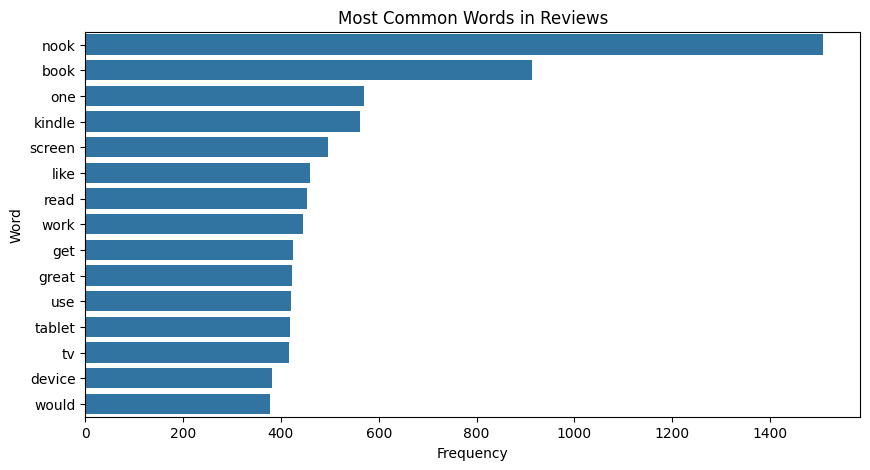

In [ ]:
# Get the 15 most common words
top_words = word_counts.most_common(15)

# Separate words and frequencies
words, counts = zip(*top_words)

# Create the bar chart
plt.figure(figsize=(10, 5))
sns.barplot(x=list(counts), y=list(words))
plt.title('Most Common Words in Reviews')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

The visualization shows that “nook” is the most frequently used word, followed by “book” and “one.” Other common words such as “kindle,” “screen,” “read,” and “tablet” suggest that many reviews focus on reading devices and the user experience. Overall, the frequent words indicate that the reviews mainly discuss Nook/Kindle devices, reading, and device features.


#### 3.12 Find the most common words in each sentiment category

In [ ]:
# Get the most common words for each sentiment
for sentiment in df['sentiment_label'].unique():
    words = [
        word
        for tokens in df[df['sentiment_label'] == sentiment]['processed_tokens']
        for word in tokens
    ]

    print(f"\nTop 10 words in {sentiment} reviews:")
    print(Counter(words).most_common(10))


Top 10 words in negative reviews:
[('nook', 252), ('book', 190), ('get', 97), ('one', 96), ('bn', 95), ('device', 84), ('read', 83), ('time', 79), ('kindle', 79), ('would', 78)]

Top 10 words in positive reviews:
[('nook', 1075), ('book', 612), ('one', 411), ('kindle', 401), ('great', 368), ('tv', 357), ('screen', 340), ('like', 328), ('work', 317), ('read', 305)]

Top 10 words in neutral reviews:
[('nook', 182), ('book', 111), ('screen', 84), ('kindle', 81), ('read', 66), ('one', 62), ('like', 61), ('device', 61), ('tablet', 57), ('work', 54)]



The results show that **“nook” and “book”** are the most common words across all three sentiment categories. Positive reviews contain more clearly favorable words such as **“great”** and **“work,”** while negative reviews include words such as **“get,” “device,”** and **“would,”** suggesting discussions about product use and possible issues. Neutral reviews focus more on **“screen,” “device,” “tablet,”** and **“work,”** indicating descriptions of product features and usage rather than strong opinions.

This shows that the language differs across sentiment categories, while still sharing common product-related terms.


### 3.2 Most Common Bigrams
Grouped two consecutive words together and counted how often each pair appears. This helps identify common phrases and word combinations in the reviews.

In [ ]:
# Create bigrams from all processed words
bigrams = list(ngrams(all_words, 2))

# Count the most common bigrams
bigram_counts = Counter(bigrams)

# Display the 20 most common bigrams
bigram_counts.most_common(20)

[(('barnes', 'noble'), 152),
 (('nook', 'color'), 127),
 (('battery', 'life'), 87),
 (('touch', 'screen'), 81),
 (('sd', 'card'), 80),
 (('nook', 'hd'), 74),
 (('work', 'great'), 63),
 (('nook', 'tablet'), 63),
 (('work', 'well'), 57),
 (('read', 'book'), 55),
 (('kindle', 'fire'), 55),
 (('wall', 'mount'), 51),
 (('simple', 'touch'), 44),
 (('android', 'tablet'), 39),
 (('customer', 'service'), 38),
 (('nook', 'simple'), 37),
 (('bn', 'store'), 35),
 (('easy', 'install'), 34),
 (('original', 'nook'), 34),
 (('ebook', 'reader'), 33)]

The most common bigram is **“barnes noble”**, followed by phrases such as **“nook color,” “battery life,” “touch screen,”** and **“sd card.”** This shows that customers often discuss **specific products, device features, and user experience**. Phrases like **“work great”** and **“work well”** also suggest that customers frequently describe product performance.


### 3.21 Most Common Bigrams visualization

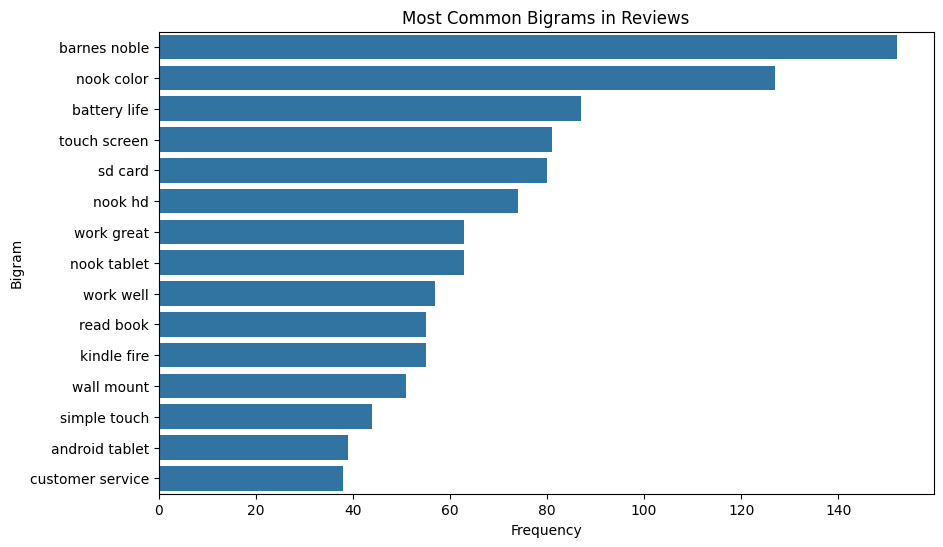

In [ ]:
# Get the 15 most common bigrams
top_bigrams = bigram_counts.most_common(15)

# Convert bigrams into readable phrases
phrases = [' '.join(bigram) for bigram, count in top_bigrams]
counts = [count for bigram, count in top_bigrams]

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=counts, y=phrases)
plt.title('Most Common Bigrams in Reviews')
plt.xlabel('Frequency')
plt.ylabel('Bigram')
plt.show()

The visualization shows that “barnes noble” is the most common bigram, followed by “nook color” and “battery life.” Other frequent phrases such as “touch screen,” “sd card,” and “nook hd” show that customers often discuss specific devices and their features. Overall, the bigrams highlight discussions around Nook products, device features, and user experience.

#### 3.22 Compare bigrams by sentiment

In [ ]:
# Find the most common bigrams for each sentiment
for sentiment in df['sentiment_label'].unique():
    words = [
        word
        for tokens in df[df['sentiment_label'] == sentiment]['processed_tokens']
        for word in tokens
    ]

    sentiment_bigrams = Counter(ngrams(words, 2))

    print(f"\nTop 10 bigrams in {sentiment} reviews:")
    print(sentiment_bigrams.most_common(10))


Top 10 bigrams in negative reviews:
[(('barnes', 'noble'), 37), (('customer', 'service'), 26), (('credit', 'card'), 21), (('free', 'book'), 13), (('battery', 'life'), 13), (('app', 'store'), 13), (('read', 'book'), 12), (('nook', 'color'), 12), (('touch', 'screen'), 11), (('every', 'time'), 11)]

Top 10 bigrams in positive reviews:
[(('barnes', 'noble'), 101), (('nook', 'color'), 92), (('sd', 'card'), 61), (('work', 'great'), 59), (('battery', 'life'), 59), (('touch', 'screen'), 56), (('nook', 'hd'), 56), (('work', 'well'), 48), (('nook', 'tablet'), 47), (('wall', 'mount'), 46)]

Top 10 bigrams in neutral reviews:
[(('nook', 'color'), 23), (('battery', 'life'), 15), (('touch', 'screen'), 14), (('barnes', 'noble'), 14), (('nook', 'hd'), 14), (('web', 'browser'), 9), (('original', 'nook'), 9), (('work', 'fine'), 8), (('app', 'store'), 8), (('sd', 'card'), 8)]



The bigrams show clear differences across sentiment categories. **Negative reviews** frequently mention **“customer service,” “credit card,” “battery life,”** and **“every time,”** suggesting that complaints often relate to service, payment issues, and product problems. **Positive reviews** contain phrases such as **“work great,” “work well,” “battery life,”** and **“touch screen,”** showing more positive discussions of product performance and features. **Neutral reviews** focus mainly on product features such as **“nook color,” “battery life,” “touch screen,”** and **“web browser.”**

Overall, the bigrams provide deeper insight into **what customers are discussing within each sentiment category**, strengthening our analysis of domain language patterns.



### 3.3 Most Common Trigrams

Grouped three consecutive words together and counted how often each combination appears. This helps identify longer and more specific phrases used in the reviews.



In [ ]:
# Create trigrams from all processed words
trigrams = list(ngrams(all_words, 3))

# Count the most common trigrams
trigram_counts = Counter(trigrams)

# Display the 20 most common trigrams
trigram_counts.most_common(20)

[(('nook', 'simple', 'touch'), 36),
 (('micro', 'sd', 'card'), 21),
 (('barnes', 'noble', 'nook'), 12),
 (('adobe', 'digital', 'edition'), 10),
 (('barnes', 'noble', 'store'), 9),
 (('sd', 'card', 'slot'), 9),
 (('access', 'google', 'play'), 8),
 (('google', 'play', 'store'), 8),
 (('kindle', 'fire', 'hd'), 8),
 (('acer', 'aspire', 'one'), 7),
 (('book', 'barnes', 'noble'), 7),
 (('access', 'android', 'market'), 7),
 (('tv', 'wall', 'mount'), 7),
 (('apps', 'google', 'play'), 7),
 (('page', 'turning', 'button'), 6),
 (('book', 'want', 'read'), 6),
 (('ebooks', 'local', 'library'), 6),
 (('nook', 'battery', 'life'), 6),
 (('flat', 'screen', 'tv'), 6),
 (('bn', 'app', 'store'), 6)]

The most common trigram is **“nook simple touch,”** followed by phrases such as **“micro sd card,” “barnes noble nook,”** and **“google play store.”** These phrases show that reviews often focus on **specific devices, features, apps, and storage options**. This gives us more detailed insight into what customers discuss about the products.


#### 3.31 Compare trigrams by sentiment


In [ ]:
# Find the most common trigrams for each sentiment
for sentiment in df['sentiment_label'].unique():
    words = [
        word
        for tokens in df[df['sentiment_label'] == sentiment]['processed_tokens']
        for word in tokens
    ]

    sentiment_trigrams = Counter(ngrams(words, 3))

    print(f"\nTop 10 trigrams in {sentiment} reviews:")
    print(sentiment_trigrams.most_common(10))


Top 10 trigrams in negative reviews:
[(('nook', 'simple', 'touch'), 10), (('find', 'free', 'book'), 5), (('bn', 'app', 'store'), 5), (('scotia', 'master', 'card'), 4), (('book', 'barnes', 'noble'), 3), (('barnes', 'noble', 'would'), 3), (('way', 'directional', 'key'), 3), (('home', 'button', 'top'), 3), (('access', 'android', 'market'), 3), (('customer', 'service', 'told'), 3)]

Top 10 trigrams in positive reviews:
[(('nook', 'simple', 'touch'), 24), (('micro', 'sd', 'card'), 19), (('barnes', 'noble', 'nook'), 10), (('adobe', 'digital', 'edition'), 9), (('acer', 'aspire', 'one'), 7), (('barnes', 'noble', 'store'), 7), (('tv', 'wall', 'mount'), 7), (('apps', 'google', 'play'), 7), (('google', 'play', 'store'), 7), (('kindle', 'fire', 'hd'), 7)]

Top 10 trigrams in neutral reviews:
[(('sd', 'card', 'slot'), 3), (('single', 'use', 'battery'), 2), (('book', 'public', 'library'), 2), (('truck', 'specific', 'gps'), 2), (('ton', 'county', 'road'), 2), (('nice', 'web', 'browser'), 2), (('down

The trigram results show that **negative reviews** contain phrases related to difficulties and problems, such as **“customer service told,” “scotia master card,”** and **“way directional key.”** Positive reviews focus more on **products, technology, and features**, with phrases such as **“micro sd card,” “barnes noble nook,”** and **“google play store.”** Neutral reviews are more descriptive, mentioning features and usage such as **“sd card slot,” “web browser,”** and **“finger across screen.”**

This suggests that the type of language used changes with sentiment: **negative reviews discuss problems, positive reviews discuss products and features, and neutral reviews mainly describe product characteristics and usage.**


### 3.4 Language Patterns by Category

The language patterns differ across the sentiment categories. **Negative reviews** contain phrases related to problems and difficulties, such as **“customer service told”** and **“way directional key.”** **Positive reviews** focus more on products and features, including **“micro sd card,” “barnes noble nook,”** and **“google play store.”** **Neutral reviews** are more descriptive, with phrases such as **“sd card slot,” “web browser,”** and **“finger across screen.”**

This implies that customer feedback can reveal **what customers like, what problems they experience, and which product features they discuss**. For our scenario, these patterns can help identify areas for improving products and customer experience.


## **Step 4: Conclusion: Reporting Insights**

Yes. We should include the **language patterns we identified** because they are one of the main findings of the analysis.

The preprocessing steps—**lowercasing, URL and punctuation removal, tokenization, stopword removal, and lemmatization**—reduced unnecessary text and made the reviews more consistent for analysis. Our comparison of stemming and lemmatization also showed that **lemmatization produced more meaningful word forms**, so it was selected for the final preprocessing.

The frequency analysis showed that words such as **“nook,” “book,” “kindle,” “screen,” “read,”** and **“tablet”** were common, showing that customers mainly discuss **reading devices, books, and product features**. Bigrams and trigrams provided more detailed patterns, including **“battery life,” “touch screen,” “work great,” “customer service told,”** and **“micro sd card.”**

We also identified clear **language patterns across sentiment categories**. Negative reviews were more likely to contain phrases related to difficulties, such as **“customer service told,”** while positive reviews included phrases such as **“work great”** and **“google play store,”** reflecting product performance and features. Neutral reviews were more descriptive, with phrases such as **“sd card slot”** and **“web browser.”**

These findings suggest that customers mainly discuss **product features, performance, reading experience, and problems they encounter**. The cleaned and structured text, together with the identified sentiment-specific language patterns, provides a strong foundation for the broader purpose of the study: **using text data for sentiment analysis and future text classification**, using the existing positive, negative, and neutral labels.


